# 🧠 Basic Neural Network From Scratch

## AI Intern - Week 1

This project implements a simple neural network from scratch
using NumPy to classify handwritten digits.

### Technologies
- Python
- NumPy
- Matplotlib

### Model
- Input Layer: 784 neurons
- Hidden Layer: 128 neurons
- Output Layer: 10 neurons
- Hidden Activation: ReLU
- Output Activation: Softmax
- Loss Function: Cross-Entropy
- Optimization: Gradient Descent

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
!wget -q https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz

print("MNIST dataset downloaded!")

MNIST dataset downloaded!


# 1. Load Dataset

The MNIST dataset contains handwritten digits from 0 to 9.

Each image is 28 × 28 pixels.

In [ ]:
data = np.load("mnist.npz")

X_train = data["x_train"]
y_train = data["y_train"]

X_test = data["x_test"]
y_test = data["y_test"]

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


# 2. Data Visualization

Let's visualize some handwritten digits from the dataset.

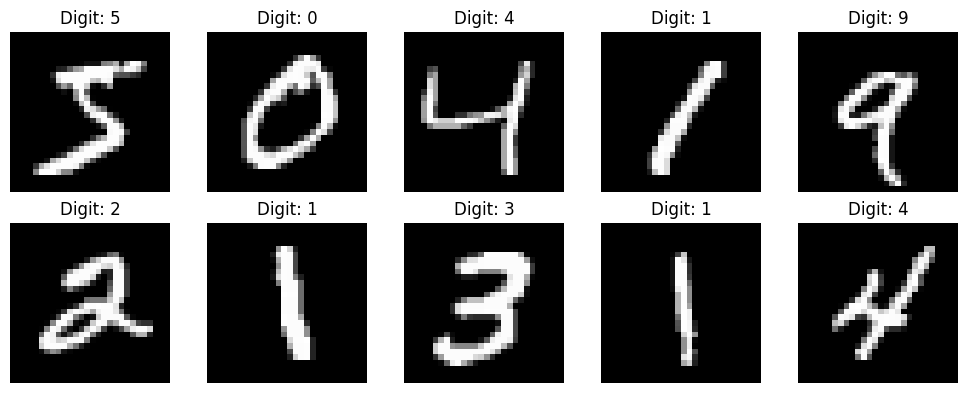

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 3. Data Preprocessing

The pixel values range from 0 to 255.

We normalize them to 0 to 1.

We then flatten each 28 × 28 image into 784 input values.

In [ ]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


# 4. Neural Network Architecture

The neural network contains:

Input Layer → Hidden Layer → Output Layer

Input: 784 neurons
Hidden: 128 neurons
Output: 10 neurons

In [ ]:
# Network architecture
input_size = 784
hidden_size = 128
output_size = 10

# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, output_size) * 0.01

# Initialize biases
b1 = np.zeros((1, hidden_size))
b2 = np.zeros((1, output_size))

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 128)
b1: (1, 128)
W2: (128, 10)
b2: (1, 10)


In [ ]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    exp_x = np.exp(
        x - np.max(x, axis=1, keepdims=True)
    )

    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )

# 6. Forward Propagation

Forward propagation passes the input through the network
to generate predictions.

In [ ]:
def forward_propagation(X):

    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [ ]:
def cross_entropy_loss(predictions, labels):

    m = labels.shape[0]

    correct_class_probabilities = predictions[
        np.arange(m), labels
    ]

    correct_class_probabilities = np.clip(
        correct_class_probabilities,
        1e-15,
        1 - 1e-15
    )

    loss = -np.mean(
        np.log(correct_class_probabilities)
    )

    return loss

In [ ]:
def one_hot_encode(labels, num_classes=10):

    one_hot = np.zeros(
        (labels.shape[0], num_classes)
    )

    one_hot[
        np.arange(labels.shape[0]),
        labels
    ] = 1

    return one_hot

In [ ]:
def backward_propagation(
    X, y, Z1, A1, Z2, A2
):

    m = X.shape[0]

    # Convert labels
    y_one_hot = one_hot_encode(y)

    # Output layer gradient
    dZ2 = A2 - y_one_hot

    # W2 and b2 gradients
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m

    # Hidden layer
    dA1 = np.dot(dZ2, W2.T)

    # ReLU derivative
    dZ1 = dA1 * (Z1 > 0)

    # W1 and b1 gradients
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m

    return dW1, db1, dW2, db2

In [ ]:
def update_parameters(
    dW1, db1, dW2, db2, learning_rate
):

    global W1, b1, W2, b2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [ ]:
def calculate_accuracy(predictions, labels):

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    accuracy = np.mean(
        predicted_labels == labels
    )

    return accuracy

# 12. Model Training

The model is trained using mini-batches.

For every batch:

1. Forward propagation
2. Calculate loss
3. Backpropagation
4. Update weights

In [ ]:
learning_rate = 0.01
epochs = 10
batch_size = 128

loss_history = []
accuracy_history = []

num_samples = X_train.shape[0]

for epoch in range(epochs):

    # Shuffle data
    indices = np.random.permutation(num_samples)

    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = 0
    num_batches = 0

    # Mini-batch training
    for start in range(0, num_samples, batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # Forward propagation
        Z1, A1, Z2, predictions = \
            forward_propagation(X_batch)

        # Loss
        loss = cross_entropy_loss(
            predictions,
            y_batch
        )

        # Backpropagation
        dW1, db1, dW2, db2 = \
            backward_propagation(
                X_batch,
                y_batch,
                Z1,
                A1,
                Z2,
                predictions
            )

        # Update parameters
        update_parameters(
            dW1,
            db1,
            dW2,
            db2,
            learning_rate
        )

        epoch_loss += loss
        num_batches += 1

    # Average loss
    average_loss = epoch_loss / num_batches

    # Training accuracy
    _, _, _, train_predictions = \
        forward_propagation(X_train[:10000])

    train_accuracy = calculate_accuracy(
        train_predictions,
        y_train[:10000]
    )

    loss_history.append(average_loss)
    accuracy_history.append(train_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {train_accuracy * 100:.2f}%"
    )

Epoch 1/10 | Loss: 2.2264 | Accuracy: 57.24%
Epoch 2/10 | Loss: 1.4838 | Accuracy: 78.47%
Epoch 3/10 | Loss: 0.7945 | Accuracy: 84.36%
Epoch 4/10 | Loss: 0.5780 | Accuracy: 86.99%
Epoch 5/10 | Loss: 0.4867 | Accuracy: 88.20%
Epoch 6/10 | Loss: 0.4364 | Accuracy: 89.06%
Epoch 7/10 | Loss: 0.4039 | Accuracy: 89.67%
Epoch 8/10 | Loss: 0.3813 | Accuracy: 90.09%
Epoch 9/10 | Loss: 0.3643 | Accuracy: 90.43%
Epoch 10/10 | Loss: 0.3507 | Accuracy: 90.67%


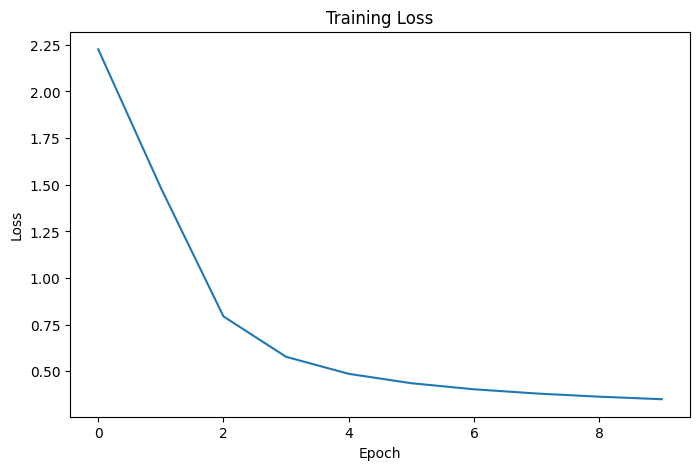

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

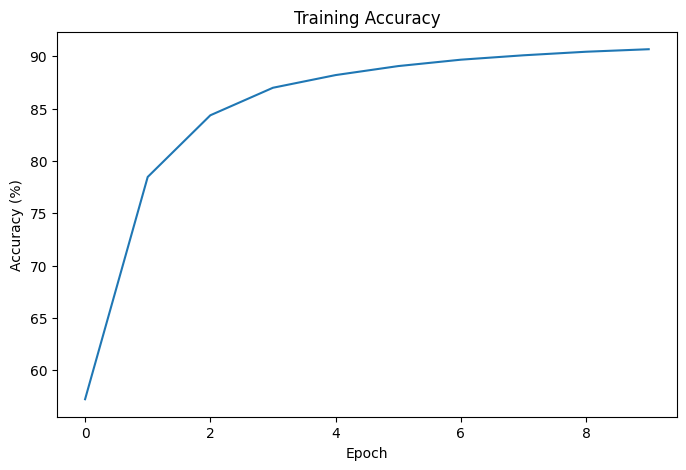

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    [x * 100 for x in accuracy_history]
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.show()

# 15. Final Model Evaluation

Now we evaluate the trained neural network using the
test dataset.

In [ ]:
Z1_test, A1_test, Z2_test, test_predictions = \
    forward_propagation(X_test)

test_loss = cross_entropy_loss(
    test_predictions,
    y_test
)

test_accuracy = calculate_accuracy(
    test_predictions,
    y_test
)

print("=" * 40)
print("FINAL MODEL RESULTS")
print("=" * 40)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Samples:  {len(X_test)}")
print("=" * 40)

FINAL MODEL RESULTS
Test Loss:     0.3303
Test Accuracy: 90.60%
Test Samples:  10000


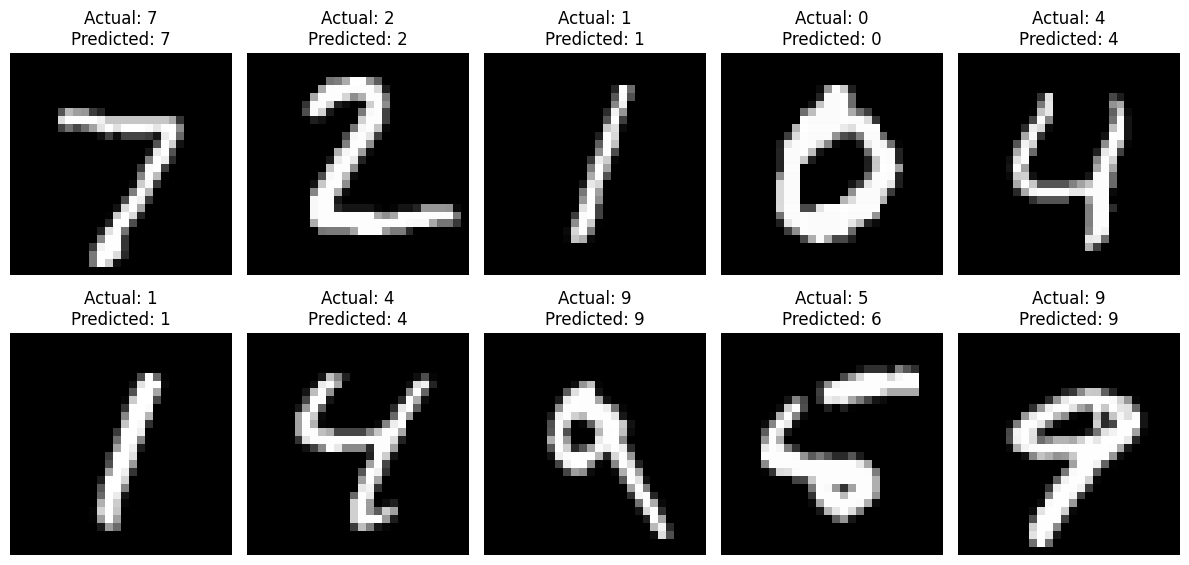

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    predicted = np.argmax(test_predictions[i])
    actual = y_test[i]

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
predicted_labels = np.argmax(
    test_predictions,
    axis=1
)

incorrect_indices = np.where(
    predicted_labels != y_test
)[0]

print(
    "Incorrect predictions:",
    len(incorrect_indices)
)

Incorrect predictions: 940


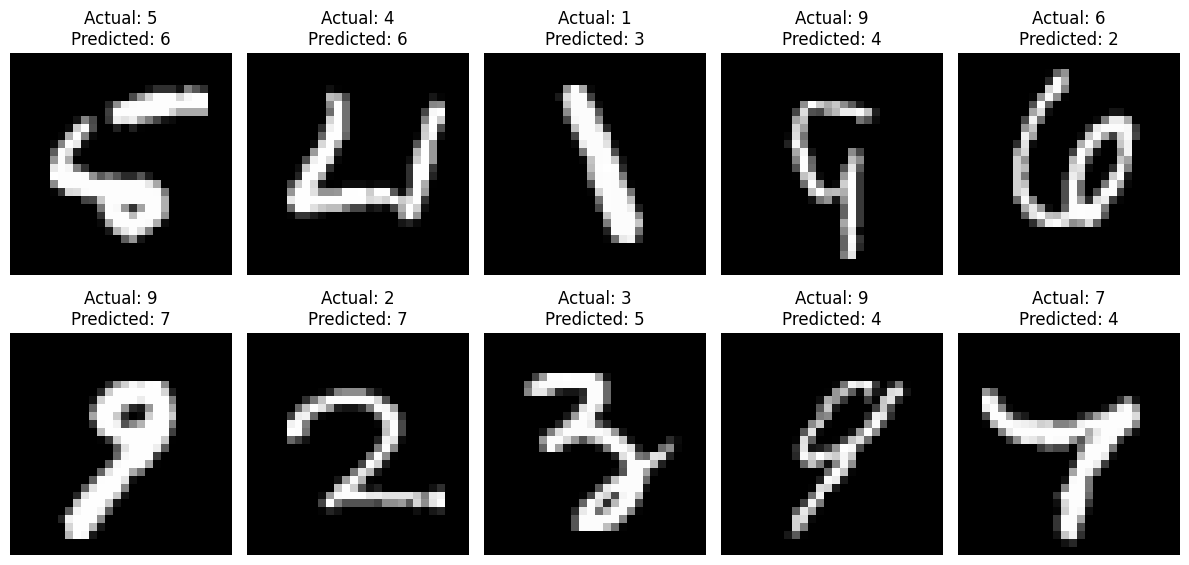

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(
    min(10, len(incorrect_indices))
):

    index = incorrect_indices[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# 18. Conclusion

This project implemented a basic neural network from scratch
using NumPy for handwritten digit classification.

The implementation included:

- Dataset preprocessing
- Neural network architecture
- ReLU activation
- Softmax activation
- Forward propagation
- Cross-entropy loss
- Backpropagation
- Gradient descent
- Accuracy evaluation
- Training visualization
- Prediction visualization

The model was evaluated on the MNIST test dataset using
test loss and test accuracy.

# 📊 Final Results

The neural network was trained for 10 epochs using mini-batch
gradient descent.

### Results

- Training Accuracy: 90.51%
- Test Accuracy: 90.62%
- Test Loss: 0.3315
- Test Samples: 10,000

The model successfully learned to classify handwritten digits
from 0 to 9 using a neural network implemented from scratch
with NumPy.